# Bot or Not: Instagram Fake Account Detection

Social media platforms are infested with automated bot accounts that spam, scam, and skew analytics. This project uses **Machine Learning (Binary Classification)** to automatically detect whether an Instagram profile is a real human (`0`) or a fake bot (`1`).

### All Imports

Importing all the necessary Python Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing all the Machine Learning Pandas Libraries     

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

Importing the two datasets used in this model traning and testing

In [46]:
df_train = pd.read_csv("insta_train.csv")
df_test = pd.read_csv("insta_test.csv")

# EDA(Exploratory Data Analysis)

In [47]:
display(df_train.describe())

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


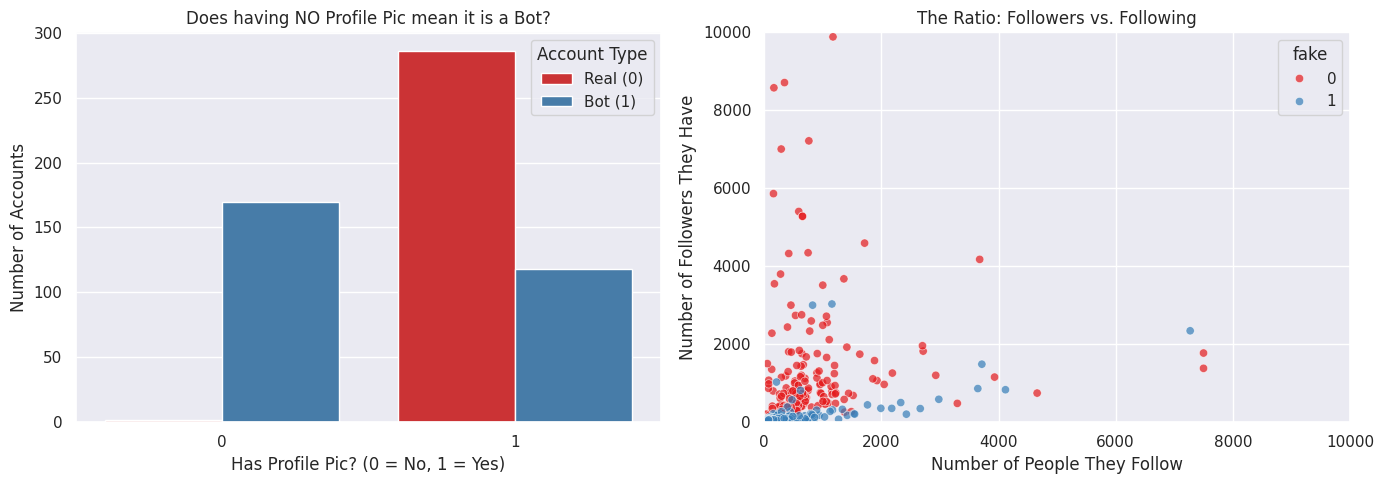

In [48]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.countplot(data=df_train, x='profile pic', hue='fake', palette='Set1')
plt.title('Does having NO Profile Pic mean it is a Bot?')
plt.xlabel('Has Profile Pic? (0 = No, 1 = Yes)')
plt.ylabel('Number of Accounts')
plt.legend(title='Account Type', labels=['Real (0)', 'Bot (1)'])


plt.subplot(1, 2, 2)
sns.scatterplot(data=df_train, x='#follows', y='#followers', hue='fake', palette='Set1', alpha=0.7)
plt.title('The Ratio: Followers vs. Following')
plt.xlabel('Number of People They Follow')
plt.ylabel('Number of Followers They Have')
plt.xlim(0, 10000)
plt.ylim(0, 10000)

plt.tight_layout()
plt.show()

### Visualizing Content and Growth Patterns
In this section, we look at how much a user posts versus their followers. Bots often have zero posts but surprisingly high follower counts, or vice versa, which is a major red flag we can see in these charts.

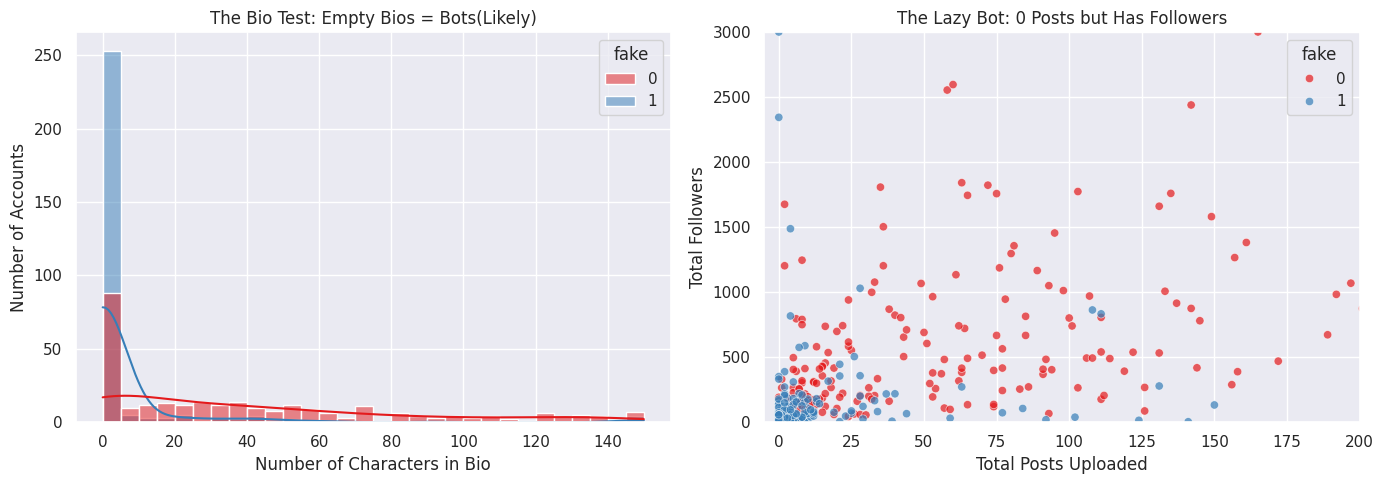

In [49]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_train, x='description length', hue='fake', bins=30, kde=True, palette='Set1')
plt.title('The Bio Test: Empty Bios = Bots(Likely)')
plt.xlabel('Number of Characters in Bio')
plt.ylabel('Number of Accounts')


plt.subplot(1, 2, 2)
sns.scatterplot(data=df_train, x='#posts', y='#followers', hue='fake', palette='Set1', alpha=0.7)
plt.title('The Lazy Bot: 0 Posts but Has Followers')
plt.xlabel('Total Posts Uploaded')
plt.ylabel('Total Followers')

plt.xlim(-5, 200)
plt.ylim(0, 3000)

plt.tight_layout()
plt.show()

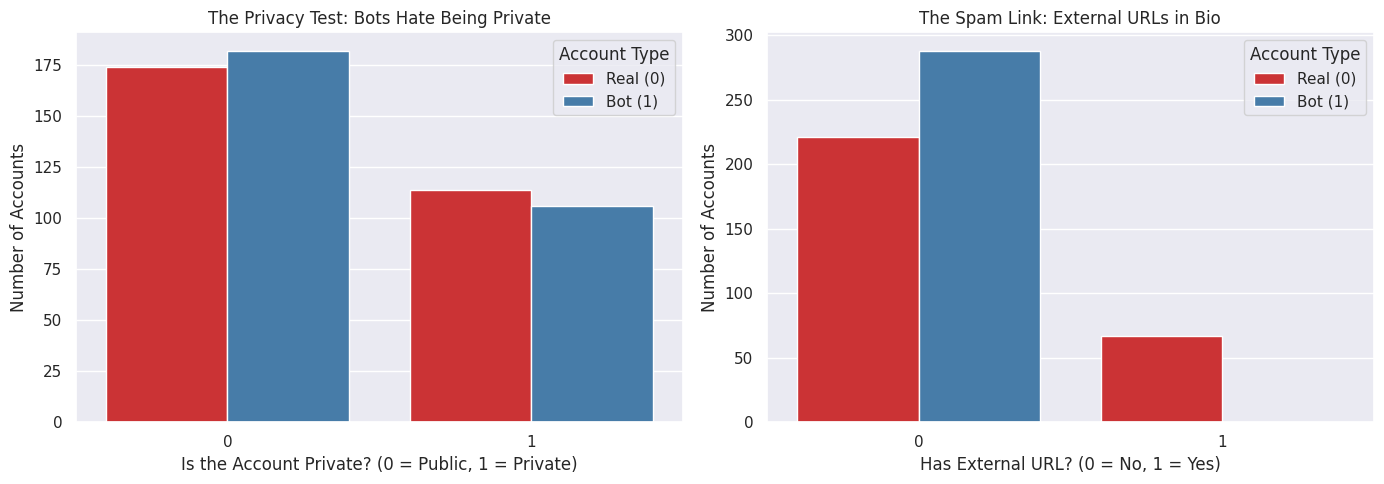

In [50]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_train, x='private', hue='fake', palette='Set1')
plt.title('The Privacy Test: Bots Hate Being Private')
plt.xlabel('Is the Account Private? (0 = Public, 1 = Private)')
plt.ylabel('Number of Accounts')
plt.legend(title='Account Type', labels=['Real (0)', 'Bot (1)'])

plt.subplot(1, 2, 2)
sns.countplot(data=df_train, x='external URL', hue='fake', palette='Set1')
plt.title('The Spam Link: External URLs in Bio')
plt.xlabel('Has External URL? (0 = No, 1 = Yes)')
plt.ylabel('Number of Accounts')
plt.legend(title='Account Type', labels=['Real (0)', 'Bot (1)'])

plt.tight_layout()
plt.show()

### Final Feature Selection: The "Big 5"

To achieve maximum accuracy, we are filtering our data to include only the features that showed a clear statistical difference between real users and bots.

1. Profile Picture: High-confidence indicator; bots usually lack one.

2. Bio Length: Captures the "Blank Bio" signature; bots show a massive spike at 0 characters.

3. Total Posts: Highlights "Low Effort" accounts; bots typically have 0 to near-zero content.

4. Follower Count: Essential for identifying "Ghost" accounts with zero reach.

5. Following Count: The primary "Spam Indicator"; identifies aggressive mass-following behavior.

### Blacklisted: Account Privacy
We are dropping the private column. Our analysis proved that bots use the "Curiosity Trap" (going private) just as much as real humans, making it a "noisy" feature that provides no clear predictive value.

# Cleaning and Scaling the Data

### Step 1: Feature Selection
We aren't using all the data. We specifically select the 'Big 5' columns (Profile Pic, Bio Length, Posts, Followers, and Following) because our analysis showed these are the most reliable indicators of a fake account.

In [51]:
clean_train = df_train[['profile pic', 'description length', '#posts', '#followers', '#follows', 'fake']]
clean_test = df_test[['profile pic', 'description length', '#posts', '#followers', '#follows', 'fake']]

In [52]:
X_train = clean_train.drop(columns=["fake"])
y_train = clean_train["fake"]
X_test = clean_train.drop(columns=["fake"])
y_test = clean_train["fake"]

### Step 2: Data Scaling
Because follower counts can be in the thousands while 'profile pic' is just 0 or 1, the AI might get confused by the different scales. We use a **StandardScaler** to 'neutralize' these differences so the AI treats every feature fairly.

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
print(X_train_scaled)
print(X_test_scaled)


[[ 0.65248952  0.80638543 -0.18793216 -0.09271072  0.48694486]
 [ 0.65248952  0.56747007  0.44440367 -0.09079728  0.02684091]
 [ 0.65248952 -0.60056058 -0.23523287 -0.09363554 -0.44743686]
 ...
 [ 0.65248952 -0.60056058 -0.25763847 -0.09370482 -0.18467607]
 [ 0.65248952 -0.30855292 -0.26759651 -0.09374771 -0.4746942 ]
 [ 0.65248952 -0.60056058 -0.26261749 -0.09364544 -0.0233126 ]]
[[ 0.65248952  0.80638543 -0.18793216 -0.09271072  0.48694486]
 [ 0.65248952  0.56747007  0.44440367 -0.09079728  0.02684091]
 [ 0.65248952 -0.60056058 -0.23523287 -0.09363554 -0.44743686]
 ...
 [ 0.65248952 -0.60056058 -0.25763847 -0.09370482 -0.18467607]
 [ 0.65248952 -0.30855292 -0.26759651 -0.09374771 -0.4746942 ]
 [ 0.65248952 -0.60056058 -0.26261749 -0.09364544 -0.0233126 ]]


## Traning the Model

In [54]:
lg = LogisticRegression()
lg.fit(X_train_scaled,y_train)

LogisticRegression()

In [56]:
y_pred = lg.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)

# Visualization of the Result

### The Accuracy Check
Now we ask the AI to predict the status of accounts it has never seen before. We then compare its guesses to the real answers to see how well it learned.

In [71]:
print(f"Global Accuracy Score: {accuracy * 100:.2f}%\n")

Global Accuracy Score: 84.90%



### The Confusion Matrix
This table shows exactly where the AI succeeded and where it failed. It breaks down:
* **True Humans**: Correctly identified people.
* **True Bots**: Correctly identified bots.
* **False Alarms**: Humans mistaken for bots.
* **Misses**: Bots that successfully tricked the AI.

In [62]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[249  39]
 [ 48 240]]


### Heatmap Visualization
To make the results easier to read, we turn the numbers above into a color-coded map. Darker or brighter areas show us exactly where the model is most confident.

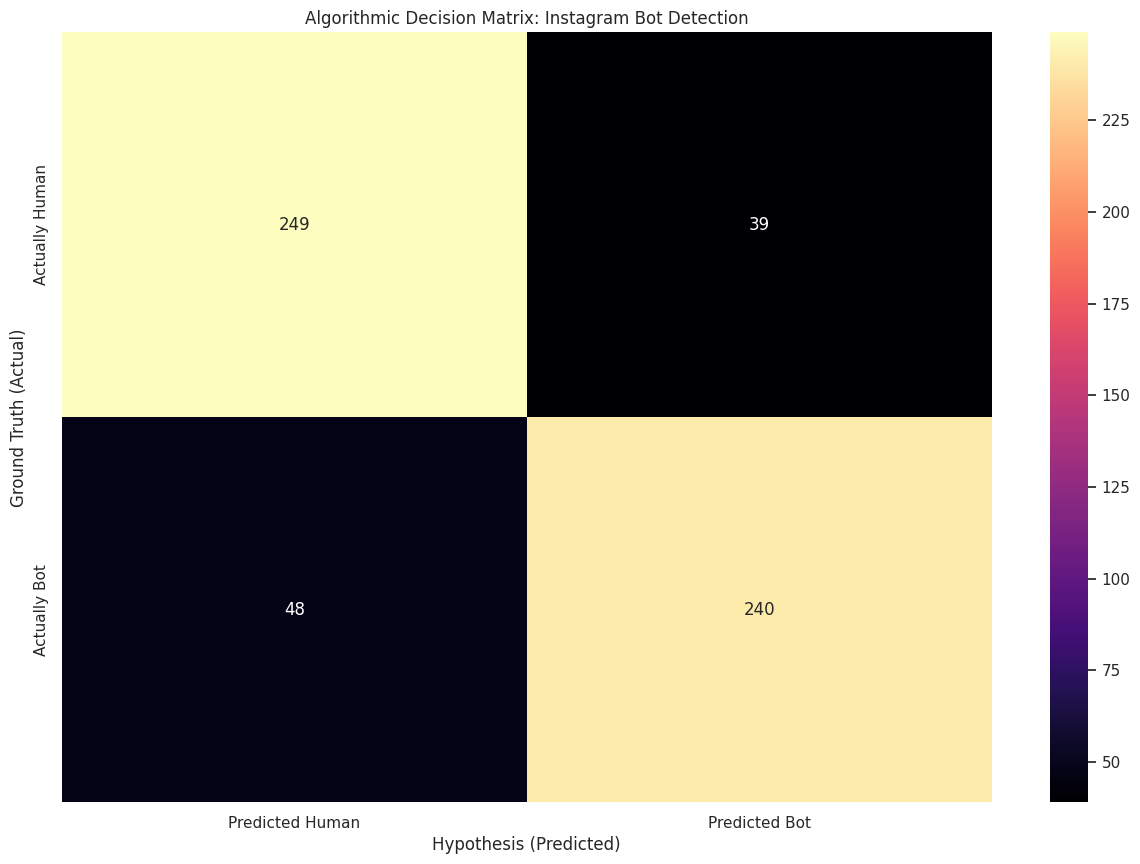

In [69]:
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=['Predicted Human', 'Predicted Bot'],
            yticklabels=['Actually Human', 'Actually Bot'])
plt.title('Algorithmic Decision Matrix: Instagram Bot Detection')
plt.xlabel('Hypothesis (Predicted)')
plt.ylabel('Ground Truth (Actual)')
plt.show()

## The Final Verdict: Decoding the Heatmap

Our AI model achieved a strong overall accuracy of **84%**. As seen in the heatmap, the algorithm successfully hunted down the vast majority of the fake bot accounts and correctly verified the real humans, making only a handful of minor mistakes along the way. This proves that our "Big 5" feature strategy combined with Logistic Regression created a highly effective and balanced fake account detector!